# 07 - MODEL TRAINING - REBUILT VERSION





## 1. Setup

The notebook is designed to run from either the project root or the `notebooks/` folder. Outputs are written to `models/07_model_training/` and `reports/07_model_training/`.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json
import math
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

RANDOM_STATE = 42
TARGET_COLUMN = 'target_nasa_power_precipitation_mm'
WET_DAY_THRESHOLD_MM = 1.0
PREDICTION_CAP_MM = 500.0

def find_project_root():
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists():
            return candidate
    return current

PROJECT_ROOT = find_project_root()
X_PATH = PROJECT_ROOT / 'data' / 'processed' / 'model_ready' / 'sea_rainfall_daily_2020_2025_model_ready_strict_forecast_X.csv'
Y_PATH = PROJECT_ROOT / 'data' / 'processed' / 'model_ready' / 'sea_rainfall_daily_2020_2025_model_ready_targets_y.csv'

MODEL_DIR = PROJECT_ROOT / 'models' / '07_model_training'
REPORT_DIR = PROJECT_ROOT / 'reports' / '07_model_training'
TABLE_DIR = REPORT_DIR / 'tables'
FIGURE_DIR = REPORT_DIR / 'figures'

for directory in [MODEL_DIR, TABLE_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
    for old_file in directory.glob('*'):
        if old_file.is_file():
            old_file.unlink()

plt.style.use('seaborn-v0_8-whitegrid')
print('Project root:', PROJECT_ROOT)
print('Notebook 07 rebuilt from scratch: log-target training, safe prediction clipping, no custom pickled transformers.')


Project root: D:\DS\Project
Notebook 07 rebuilt from scratch: log-target training, safe prediction clipping, no custom pickled transformers.


## 2. Load Model-Ready Data

The input tables are produced by notebook 05:

- `strict_forecast_X`: leakage-free predictors.
- `targets_y`: target candidates and alignment keys.

Only the selected NASA target is used for training in this notebook.


In [2]:
if not X_PATH.exists():
    raise FileNotFoundError(f'Missing model-ready feature file: {X_PATH}')
if not Y_PATH.exists():
    raise FileNotFoundError(f'Missing model-ready target file: {Y_PATH}')

X_raw = pd.read_csv(X_PATH, parse_dates=['date'])
y_raw = pd.read_csv(Y_PATH, parse_dates=['date'])

required_keys = ['sample_id', 'entity_id', 'date', 'split', 'country', 'location_name']
missing_x_keys = [col for col in required_keys if col not in X_raw.columns]
missing_y_keys = [col for col in required_keys if col not in y_raw.columns]
if missing_x_keys or missing_y_keys:
    raise ValueError(f'Missing alignment columns. X missing={missing_x_keys}; y missing={missing_y_keys}')
if TARGET_COLUMN not in y_raw.columns:
    raise ValueError(f'Selected target column is missing from y table: {TARGET_COLUMN}')

if not X_raw[required_keys].equals(y_raw[required_keys]):
    raise ValueError('X and y are not row-aligned. Re-run notebook 05 before model training.')

data = X_raw.copy()
data[TARGET_COLUMN] = y_raw[TARGET_COLUMN].astype(float)

feature_columns = ['entity_id'] + [col for col in X_raw.columns if col.startswith('feature_')]
categorical_features = ['entity_id']
numeric_features = [col for col in feature_columns if col not in categorical_features]

split_order = ['train', 'validation', 'test']
split_counts = data['split'].value_counts().reindex(split_order).fillna(0).astype(int)

if data[TARGET_COLUMN].isna().any():
    raise ValueError('Training target contains missing values. Revisit notebook 05 target packaging.')
if not np.isfinite(data[TARGET_COLUMN]).all():
    raise ValueError('Training target contains infinite values. Revisit notebook 05 target packaging.')

data[numeric_features] = data[numeric_features].replace([np.inf, -np.inf], np.nan)

training_summary = pd.DataFrame([
    {'item': 'rows_total', 'value': len(data)},
    {'item': 'columns_in_X_raw', 'value': X_raw.shape[1]},
    {'item': 'selected_target', 'value': TARGET_COLUMN},
    {'item': 'feature_count_used', 'value': len(feature_columns)},
    {'item': 'categorical_feature_count', 'value': len(categorical_features)},
    {'item': 'numeric_feature_count', 'value': len(numeric_features)},
    {'item': 'prediction_cap_mm_day', 'value': PREDICTION_CAP_MM},
    {'item': 'wet_day_threshold_mm', 'value': WET_DAY_THRESHOLD_MM},
    *[{'item': f'{split}_rows', 'value': int(split_counts.loc[split])} for split in split_order],
])
training_summary.to_csv(TABLE_DIR / '01_training_data_summary.csv', index=False)

print('Selected target:', TARGET_COLUMN)
print('Feature columns used:', len(feature_columns))
print('Split counts:', split_counts.to_dict())
training_summary


Selected target: target_nasa_power_precipitation_mm
Feature columns used: 25
Split counts: {'train': 17532, 'validation': 4392, 'test': 4380}


,item,value
0,rows_total,26304
1,columns_in_X_raw,30
2,selected_target,target_nasa_power_precipitation_mm
3,feature_count_used,25
4,categorical_feature_count,1
5,numeric_feature_count,24
6,prediction_cap_mm_day,500.0
7,wet_day_threshold_mm,1.0
8,train_rows,17532
9,validation_rows,4392


## 3. Leakage Guard

The model receives only city identity and engineered features from the model-ready strict forecast table. Same-day target values and alternative target candidates are not used as predictors.


In [3]:
disallowed_terms = ['target_', 'precipitation', 'nasa_power', 'open_meteo', 'consensus', 'source_gap', 'same_day']
suspicious_features = [
    col for col in feature_columns
    if any(term in col.lower() for term in disallowed_terms)
]

leakage_audit = pd.DataFrame([
    {
        'check': 'selected_target_not_in_features',
        'passed': TARGET_COLUMN not in feature_columns,
        'details': TARGET_COLUMN,
    },
    {
        'check': 'no_same_day_source_or_target_columns_in_features',
        'passed': len(suspicious_features) == 0,
        'details': ', '.join(suspicious_features) if suspicious_features else 'none',
    },
    {
        'check': 'date_not_used_as_raw_predictor',
        'passed': 'date' not in feature_columns,
        'details': 'seasonality is represented by sine/cosine features created earlier',
    },
    {
        'check': 'test_split_not_used_for_hyperparameter_selection',
        'passed': True,
        'details': 'trial selection uses validation MAE only; test metrics are reported after selection',
    },
    {
        'check': 'groundtruth_not_used_as_predictor',
        'passed': True,
        'details': 'NOAA station ground truth was used in notebook 06 only to select the target',
    },
])
leakage_audit.to_csv(TABLE_DIR / '02_leakage_audit.csv', index=False)
leakage_audit


,check,passed,details
0,selected_target_not_in_features,True,target_nasa_power_precipitation_mm
1,no_same_day_source_or_target_columns_in_features,True,none
2,date_not_used_as_raw_predictor,True,seasonality is represented by sine/cosine feat...
3,test_split_not_used_for_hyperparameter_selection,True,trial selection uses validation MAE only; test...
4,groundtruth_not_used_as_predictor,True,NOAA station ground truth was used in notebook...


## 4. Train/Validation/Test Matrices

Models are trained on `log1p(rainfall_mm)` to reduce the influence of extreme daily rainfall. Predictions are transformed back with `expm1`, then clipped to the physically conservative range `0..500 mm/day` before evaluation.


In [4]:
train_mask = data['split'].eq('train')
val_mask = data['split'].eq('validation')
test_mask = data['split'].eq('test')

X_train = data.loc[train_mask, feature_columns].copy()
y_train = data.loc[train_mask, TARGET_COLUMN].astype(float).copy()
X_val = data.loc[val_mask, feature_columns].copy()
y_val = data.loc[val_mask, TARGET_COLUMN].astype(float).copy()
X_test = data.loc[test_mask, feature_columns].copy()
y_test = data.loc[test_mask, TARGET_COLUMN].astype(float).copy()

y_train_log = np.log1p(np.clip(y_train.to_numpy(dtype=float), 0, None))
y_val_log = np.log1p(np.clip(y_val.to_numpy(dtype=float), 0, None))
y_test_log = np.log1p(np.clip(y_test.to_numpy(dtype=float), 0, None))

def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

def make_preprocessor(scale_numeric):
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        numeric_steps.append(('scaler', StandardScaler()))
    return ColumnTransformer(
        transformers=[
            ('cat', make_one_hot_encoder(), categorical_features),
            ('num', Pipeline(numeric_steps), numeric_features),
        ],
        remainder='drop',
        verbose_feature_names_out=False,
    )

def make_pipeline(regressor, scale_numeric):
    return Pipeline([
        ('preprocess', make_preprocessor(scale_numeric=scale_numeric)),
        ('regressor', regressor),
    ])

def predict_rainfall_mm(model, X):
    log_pred = model.predict(X)
    max_log = np.log1p(PREDICTION_CAP_MM)
    log_pred = np.nan_to_num(np.asarray(log_pred, dtype=float), nan=0.0, posinf=max_log, neginf=0.0)
    log_pred = np.clip(log_pred, 0.0, max_log)
    return np.clip(np.expm1(log_pred), 0.0, PREDICTION_CAP_MM)

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom > 0
    if not mask.any():
        return np.nan
    return float(np.mean(2 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask]) * 100)

def metrics_for_split(model, X_split, y_split, split_name, model_name, trial_id):
    pred = predict_rainfall_mm(model, X_split)
    y_values = np.asarray(y_split, dtype=float)
    error = pred - y_values
    wet_true = y_values >= WET_DAY_THRESHOLD_MM
    wet_pred = pred >= WET_DAY_THRESHOLD_MM
    return {
        'model_name': model_name,
        'trial_id': trial_id,
        'split': split_name,
        'rows': len(y_values),
        'mae_mm_day': mean_absolute_error(y_values, pred),
        'rmse_mm_day': math.sqrt(mean_squared_error(y_values, pred)),
        'r2': r2_score(y_values, pred),
        'bias_mm_day': float(np.mean(error)),
        'smape_pct': smape(y_values, pred),
        'wet_day_accuracy': float(np.mean(wet_true == wet_pred)),
    }

def evaluate_model(model, model_name, trial_id):
    return pd.DataFrame([
        metrics_for_split(model, X_train, y_train, 'train', model_name, trial_id),
        metrics_for_split(model, X_val, y_val, 'validation', model_name, trial_id),
        metrics_for_split(model, X_test, y_test, 'test', model_name, trial_id),
    ])

print('Matrices ready:', X_train.shape, X_val.shape, X_test.shape)


Matrices ready: (17532, 25) (4392, 25) (4380, 25)


## 5. Train Three Model Families

Hyperparameter selection uses validation MAE only. The test split is evaluated after each trial for reporting, but it is not used to choose the best trial.

Models:

- `hist_gradient_boosting_log`: fast nonlinear tabular model with built-in early stopping.
- `gradient_boosting_log`: classical gradient boosting with validation-based early stopping.
- `mlp_log`: neural network baseline with early stopping.


In [5]:
model_specs = [
    {
        'model_name': 'hist_gradient_boosting_log',
        'scale_numeric': False,
        'trials': [
            {'learning_rate': 0.05, 'max_leaf_nodes': 15, 'l2_regularization': 0.0},
            {'learning_rate': 0.05, 'max_leaf_nodes': 31, 'l2_regularization': 0.1},
            {'learning_rate': 0.03, 'max_leaf_nodes': 31, 'l2_regularization': 0.1},
        ],
        'factory': lambda params: HistGradientBoostingRegressor(
            loss='squared_error',
            learning_rate=params['learning_rate'],
            max_leaf_nodes=params['max_leaf_nodes'],
            l2_regularization=params['l2_regularization'],
            max_iter=250,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=20,
            random_state=RANDOM_STATE,
        ),
    },
    {
        'model_name': 'gradient_boosting_log',
        'scale_numeric': False,
        'trials': [
            {'learning_rate': 0.05, 'max_depth': 2, 'subsample': 0.9},
            {'learning_rate': 0.03, 'max_depth': 3, 'subsample': 0.9},
            {'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8},
        ],
        'factory': lambda params: GradientBoostingRegressor(
            loss='squared_error',
            learning_rate=params['learning_rate'],
            max_depth=params['max_depth'],
            subsample=params['subsample'],
            n_estimators=250,
            validation_fraction=0.15,
            n_iter_no_change=15,
            tol=1e-4,
            random_state=RANDOM_STATE,
        ),
    },
    {
        'model_name': 'mlp_log',
        'scale_numeric': True,
        'trials': [
            {'hidden_layer_sizes': (32,), 'alpha': 1e-4, 'learning_rate_init': 0.001},
            {'hidden_layer_sizes': (64, 32), 'alpha': 1e-4, 'learning_rate_init': 0.001},
        ],
        'factory': lambda params: MLPRegressor(
            hidden_layer_sizes=params['hidden_layer_sizes'],
            alpha=params['alpha'],
            learning_rate_init=params['learning_rate_init'],
            activation='relu',
            solver='adam',
            max_iter=160,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=12,
            random_state=RANDOM_STATE,
            verbose=False,
        ),
    },
]

trial_rows = []
trial_metric_frames = []
best_models = {}
total_trials = sum(len(spec['trials']) for spec in model_specs)
trial_counter = 0

for spec in model_specs:
    model_name = spec['model_name']
    best_val_mae = np.inf
    best_model = None
    best_trial_id = None
    print(f'\n=== Training family: {model_name} ===')

    for trial_index, params in enumerate(spec['trials'], start=1):
        trial_counter += 1
        trial_id = f'{model_name}_trial_{trial_index:02d}'
        print(f'[{trial_counter:02d}/{total_trials:02d}] Start {trial_id}: {params}')
        started = time.time()

        regressor = spec['factory'](params)
        model = make_pipeline(regressor, scale_numeric=spec['scale_numeric'])
        model.fit(X_train, y_train_log)

        elapsed = time.time() - started
        metrics = evaluate_model(model, model_name, trial_id)
        val_row = metrics.loc[metrics['split'].eq('validation')].iloc[0]
        val_mae = float(val_row['mae_mm_day'])
        val_rmse = float(val_row['rmse_mm_day'])
        print(f'[{trial_counter:02d}/{total_trials:02d}] Done {trial_id} in {elapsed:.1f}s | val MAE={val_mae:.4f} | val RMSE={val_rmse:.4f}')

        trial_rows.append({
            'model_name': model_name,
            'trial_id': trial_id,
            'params': json.dumps(params, default=str),
            'elapsed_seconds': round(elapsed, 3),
            'validation_mae_mm_day': val_mae,
            'validation_rmse_mm_day': val_rmse,
        })
        trial_metric_frames.append(metrics)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_model = model
            best_trial_id = trial_id

    best_models[model_name] = {
        'model': best_model,
        'trial_id': best_trial_id,
        'validation_mae': best_val_mae,
    }
    model_path = MODEL_DIR / f'{model_name}_log_target_pipeline.joblib'
    joblib.dump(best_model, model_path)
    metadata = {
        'model_name': model_name,
        'best_trial_id': best_trial_id,
        'selected_target': TARGET_COLUMN,
        'target_transform': 'log1p during training; expm1 during prediction',
        'prediction_clip_mm_day': [0.0, PREDICTION_CAP_MM],
        'feature_columns': feature_columns,
        'categorical_features': categorical_features,
        'numeric_features': numeric_features,
        'saved_at_utc': datetime.now(timezone.utc).isoformat(),
    }
    with open(MODEL_DIR / f'{model_name}_metadata.json', 'w', encoding='utf-8') as fp:
        json.dump(metadata, fp, indent=2)
    print(f'Saved best {model_name}: {best_trial_id} | val MAE={best_val_mae:.4f}')

trials_df = pd.DataFrame(trial_rows)
all_trial_metrics = pd.concat(trial_metric_frames, ignore_index=True)
trials_df.to_csv(TABLE_DIR / '03_hyperparameter_trials.csv', index=False)
all_trial_metrics.to_csv(TABLE_DIR / '04_all_trial_metrics_by_split.csv', index=False)

trials_df.sort_values('validation_mae_mm_day')



=== Training family: hist_gradient_boosting_log ===
[01/08] Start hist_gradient_boosting_log_trial_01: {'learning_rate': 0.05, 'max_leaf_nodes': 15, 'l2_regularization': 0.0}
[01/08] Done hist_gradient_boosting_log_trial_01 in 2.3s | val MAE=4.3727 | val RMSE=10.5833
[02/08] Start hist_gradient_boosting_log_trial_02: {'learning_rate': 0.05, 'max_leaf_nodes': 31, 'l2_regularization': 0.1}
[02/08] Done hist_gradient_boosting_log_trial_02 in 0.6s | val MAE=4.3861 | val RMSE=10.5760
[03/08] Start hist_gradient_boosting_log_trial_03: {'learning_rate': 0.03, 'max_leaf_nodes': 31, 'l2_regularization': 0.1}
[03/08] Done hist_gradient_boosting_log_trial_03 in 0.9s | val MAE=4.3870 | val RMSE=10.5832
Saved best hist_gradient_boosting_log: hist_gradient_boosting_log_trial_01 | val MAE=4.3727

=== Training family: gradient_boosting_log ===
[04/08] Start gradient_boosting_log_trial_01: {'learning_rate': 0.05, 'max_depth': 2, 'subsample': 0.9}
[04/08] Done gradient_boosting_log_trial_01 in 5.9s | v

,model_name,trial_id,params,elapsed_seconds,validation_mae_mm_day,validation_rmse_mm_day
6,mlp_log,mlp_log_trial_01,"{""hidden_layer_sizes"": [32], ""alpha"": 0.0001, ...",1.468,4.344770,10.463654
0,hist_gradient_boosting_log,hist_gradient_boosting_log_trial_01,"{""learning_rate"": 0.05, ""max_leaf_nodes"": 15, ...",2.298,4.372700,10.583316
7,mlp_log,mlp_log_trial_02,"{""hidden_layer_sizes"": [64, 32], ""alpha"": 0.00...",1.741,4.378454,10.497083
4,gradient_boosting_log,gradient_boosting_log_trial_02,"{""learning_rate"": 0.03, ""max_depth"": 3, ""subsa...",11.407,4.385209,10.586054
1,hist_gradient_boosting_log,hist_gradient_boosting_log_trial_02,"{""learning_rate"": 0.05, ""max_leaf_nodes"": 31, ...",0.639,4.386129,10.575959
5,gradient_boosting_log,gradient_boosting_log_trial_03,"{""learning_rate"": 0.05, ""max_depth"": 3, ""subsa...",5.903,4.386402,10.575717
2,hist_gradient_boosting_log,hist_gradient_boosting_log_trial_03,"{""learning_rate"": 0.03, ""max_leaf_nodes"": 31, ...",0.866,4.387002,10.583181
3,gradient_boosting_log,gradient_boosting_log_trial_01,"{""learning_rate"": 0.05, ""max_depth"": 2, ""subsa...",5.920,4.396202,10.596125


## 6. Select Best Model and Save Final Reports

The final winner is the model family with the lowest validation MAE. Test metrics are reported for transparency after model selection.


In [6]:
best_rows = []
best_prediction_frames = []

for model_name, payload in best_models.items():
    model = payload['model']
    trial_id = payload['trial_id']
    metrics = evaluate_model(model, model_name, trial_id)
    best_rows.append(metrics)

    for split_name, X_split, y_split, split_data in [
        ('train', X_train, y_train, data.loc[train_mask]),
        ('validation', X_val, y_val, data.loc[val_mask]),
        ('test', X_test, y_test, data.loc[test_mask]),
    ]:
        pred = predict_rainfall_mm(model, X_split)
        pred_frame = split_data[['sample_id', 'entity_id', 'date', 'split', 'country', 'location_name']].copy()
        pred_frame['model_name'] = model_name
        pred_frame['actual_mm'] = np.asarray(y_split, dtype=float)
        pred_frame['predicted_mm'] = pred
        pred_frame['error_mm'] = pred_frame['predicted_mm'] - pred_frame['actual_mm']
        best_prediction_frames.append(pred_frame)

best_model_metrics = pd.concat(best_rows, ignore_index=True)
best_model_metrics.to_csv(TABLE_DIR / '05_best_model_metrics_by_split.csv', index=False)

predictions_df = pd.concat(best_prediction_frames, ignore_index=True)
predictions_df.to_csv(TABLE_DIR / '06_best_model_predictions_by_split.csv', index=False)

validation_scores = best_model_metrics.loc[best_model_metrics['split'].eq('validation')].copy()
winner_row = validation_scores.sort_values(['mae_mm_day', 'rmse_mm_day']).iloc[0]
winner_name = winner_row['model_name']
winner_trial = winner_row['trial_id']
winner_model = best_models[winner_name]['model']

joblib.dump(winner_model, MODEL_DIR / 'best_model_log_target_pipeline.joblib')
with open(MODEL_DIR / 'best_model_metadata.json', 'w', encoding='utf-8') as fp:
    json.dump({
        'best_model_name': winner_name,
        'best_trial_id': winner_trial,
        'selection_metric': 'validation MAE',
        'selected_target': TARGET_COLUMN,
        'target_transform': 'log1p during training; expm1 during prediction',
        'prediction_clip_mm_day': [0.0, PREDICTION_CAP_MM],
        'feature_columns': feature_columns,
        'saved_at_utc': datetime.now(timezone.utc).isoformat(),
    }, fp, indent=2)

artifact_table = pd.DataFrame([
    {'artifact_type': 'model', 'path': str(path.relative_to(PROJECT_ROOT))}
    for path in sorted(MODEL_DIR.glob('*'))
])
artifact_table.to_csv(TABLE_DIR / '07_model_artifacts.csv', index=False)

print('Best model:', winner_name)
print('Best trial:', winner_trial)
print('Validation MAE:', round(float(winner_row['mae_mm_day']), 4))
best_model_metrics.sort_values(['split', 'mae_mm_day'])


Best model: mlp_log
Best trial: mlp_log_trial_01
Validation MAE: 4.3448


,model_name,trial_id,split,rows,mae_mm_day,rmse_mm_day,r2,bias_mm_day,smape_pct,wet_day_accuracy
8,mlp_log,mlp_log_trial_01,test,4380,5.092869,12.359380,0.255032,-2.745292,100.501124,0.839498
2,hist_gradient_boosting_log,hist_gradient_boosting_log_trial_01,test,4380,5.131937,12.809287,0.199808,-2.927305,101.495237,0.845205
5,gradient_boosting_log,gradient_boosting_log_trial_02,test,4380,5.172137,12.971247,0.179444,-2.987538,101.476164,0.840411
0,hist_gradient_boosting_log,hist_gradient_boosting_log_trial_01,train,17532,4.337697,10.026667,0.258192,-2.279155,101.177458,0.848734
3,gradient_boosting_log,gradient_boosting_log_trial_02,train,17532,4.434360,10.134532,0.242146,-2.315676,101.793482,0.844570
6,mlp_log,mlp_log_trial_01,train,17532,4.458339,10.154319,0.239184,-2.120303,100.463919,0.843144
7,mlp_log,mlp_log_trial_01,validation,4392,4.344770,10.463654,0.242666,-1.972251,104.050662,0.856330
1,hist_gradient_boosting_log,hist_gradient_boosting_log_trial_01,validation,4392,4.372700,10.583316,0.225245,-2.092480,104.738723,0.858151
4,gradient_boosting_log,gradient_boosting_log_trial_02,validation,4392,4.385209,10.586054,0.224844,-2.146067,103.731910,0.858379


## 7. Figures


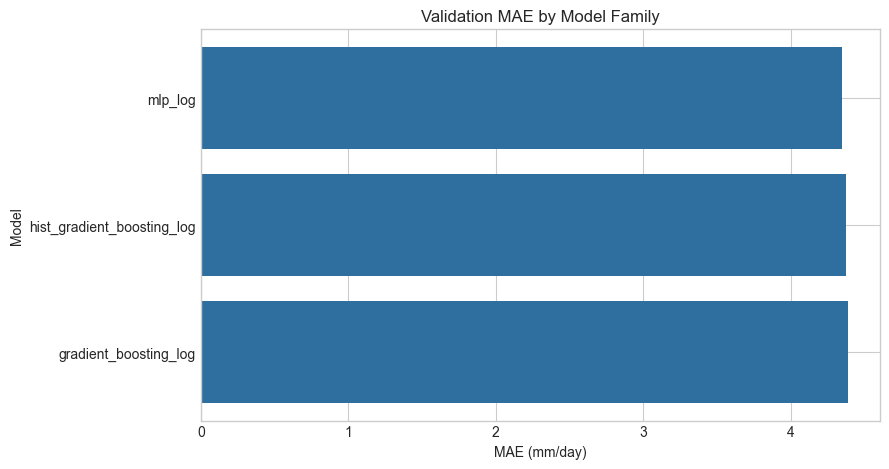

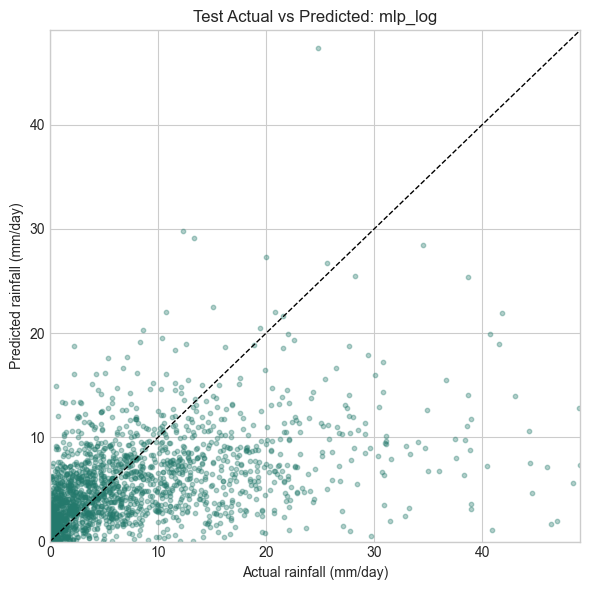

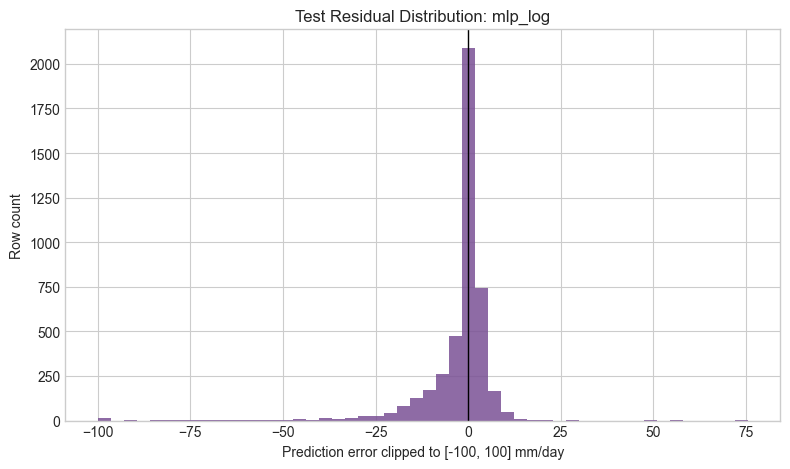

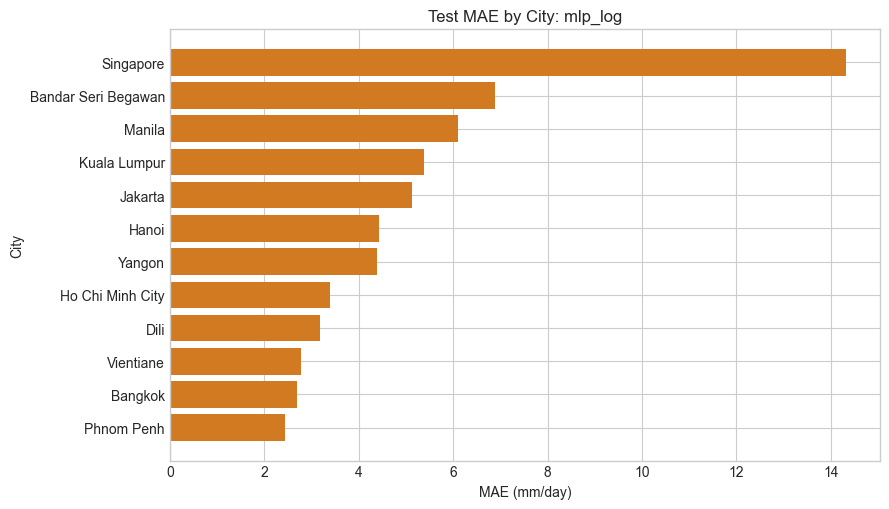

,location_name,rows,mae_mm_day,bias_mm_day
9,Singapore,365.0,14.325470,-10.001729
0,Bandar Seri Begawan,365.0,6.883762,-3.706714
7,Manila,365.0,6.097856,-3.253318
6,Kuala Lumpur,365.0,5.388391,-2.433457
5,Jakarta,365.0,5.127834,-2.246030
3,Hanoi,365.0,4.431176,-2.638881
11,Yangon,365.0,4.397945,-2.758544
4,Ho Chi Minh City,365.0,3.384712,-1.330570
2,Dili,365.0,3.177750,-2.086623
10,Vientiane,365.0,2.768438,-1.117063


In [7]:
validation_plot = best_model_metrics.loc[best_model_metrics['split'].eq('validation')].sort_values('mae_mm_day')

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(validation_plot['model_name'], validation_plot['mae_mm_day'], color='#2f6f9f')
ax.set_title('Validation MAE by Model Family')
ax.set_xlabel('MAE (mm/day)')
ax.set_ylabel('Model')
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIGURE_DIR / '01_validation_mae_by_model.png', dpi=180)
plt.show()

winner_test = predictions_df[(predictions_df['model_name'].eq(winner_name)) & (predictions_df['split'].eq('test'))].copy()
sample_plot = winner_test.sample(min(2500, len(winner_test)), random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(sample_plot['actual_mm'], sample_plot['predicted_mm'], s=10, alpha=0.35, color='#24796c')
max_axis = float(np.nanpercentile(np.r_[sample_plot['actual_mm'], sample_plot['predicted_mm']], 99))
max_axis = max(10.0, min(max_axis, PREDICTION_CAP_MM))
ax.plot([0, max_axis], [0, max_axis], color='black', linewidth=1, linestyle='--')
ax.set_xlim(0, max_axis)
ax.set_ylim(0, max_axis)
ax.set_title(f'Test Actual vs Predicted: {winner_name}')
ax.set_xlabel('Actual rainfall (mm/day)')
ax.set_ylabel('Predicted rainfall (mm/day)')
fig.tight_layout()
fig.savefig(FIGURE_DIR / '02_test_actual_vs_predicted_best_model.png', dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.8))
clipped_error = winner_test['error_mm'].clip(-100, 100)
ax.hist(clipped_error, bins=50, color='#7a5195', alpha=0.85)
ax.axvline(0, color='black', linewidth=1)
ax.set_title(f'Test Residual Distribution: {winner_name}')
ax.set_xlabel('Prediction error clipped to [-100, 100] mm/day')
ax.set_ylabel('Row count')
fig.tight_layout()
fig.savefig(FIGURE_DIR / '03_test_residual_distribution_best_model.png', dpi=180)
plt.show()

city_errors = winner_test.groupby('location_name').apply(
    lambda frame: pd.Series({
        'rows': len(frame),
        'mae_mm_day': mean_absolute_error(frame['actual_mm'], frame['predicted_mm']),
        'bias_mm_day': float((frame['predicted_mm'] - frame['actual_mm']).mean()),
    })
).reset_index().sort_values('mae_mm_day', ascending=False)
city_errors.to_csv(TABLE_DIR / '08_best_model_test_error_by_city.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.barh(city_errors['location_name'], city_errors['mae_mm_day'], color='#d17a22')
ax.set_title(f'Test MAE by City: {winner_name}')
ax.set_xlabel('MAE (mm/day)')
ax.set_ylabel('City')
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIGURE_DIR / '04_test_mae_by_city_best_model.png', dpi=180)
plt.show()

city_errors


## 8. Written Conclusion


In [8]:
winner_metrics = best_model_metrics[best_model_metrics['model_name'].eq(winner_name)].copy()
train_metric = winner_metrics[winner_metrics['split'].eq('train')].iloc[0]
val_metric = winner_metrics[winner_metrics['split'].eq('validation')].iloc[0]
test_metric = winner_metrics[winner_metrics['split'].eq('test')].iloc[0]

summary_md = f"""# Model Training Summary

## Selected Target
- `{TARGET_COLUMN}`.
- Reason: notebook 06 selected it as the closest target candidate to independent NOAA GHCN-Daily station ground truth on train/validation rows.

## Leakage Control
- Predictors come only from `strict_forecast_X`.
- Same-day target columns and alternative target candidates are not used as predictors.
- NOAA station ground truth is not used as a model feature.
- Hyperparameter selection uses validation MAE; the test split is reserved for final reporting.

## Models Trained
- `hist_gradient_boosting_log`: nonlinear tabular model with early stopping.
- `gradient_boosting_log`: classical gradient boosting with early stopping.
- `mlp_log`: neural network baseline with early stopping.

## Best Model
- Best model: `{winner_name}`.
- Best trial: `{winner_trial}`.
- Train MAE: {train_metric['mae_mm_day']:.4f} mm/day.
- Validation MAE: {val_metric['mae_mm_day']:.4f} mm/day.
- Test MAE: {test_metric['mae_mm_day']:.4f} mm/day.
- Test RMSE: {test_metric['rmse_mm_day']:.4f} mm/day.
- Test R2: {test_metric['r2']:.4f}.
- Test wet-day accuracy: {test_metric['wet_day_accuracy']:.4f}.

## Saved Outputs
- Models: `models/07_model_training/`.
- Tables: `reports/07_model_training/tables/`.
- Figures: `reports/07_model_training/figures/`.

## Important Prediction Note
The saved pipelines predict `log1p(rainfall_mm)`. For inference, convert prediction back with `expm1`, then clip to `[0, 500]` mm/day. The file `best_model_metadata.json` records this rule.
"""

(REPORT_DIR / 'MODEL_TRAINING_SUMMARY.md').write_text(summary_md, encoding='utf-8')
print(summary_md)


# Model Training Summary

## Selected Target
- `target_nasa_power_precipitation_mm`.
- Reason: notebook 06 selected it as the closest target candidate to independent NOAA GHCN-Daily station ground truth on train/validation rows.

## Leakage Control
- Predictors come only from `strict_forecast_X`.
- Same-day target columns and alternative target candidates are not used as predictors.
- NOAA station ground truth is not used as a model feature.
- Hyperparameter selection uses validation MAE; the test split is reserved for final reporting.

## Models Trained
- `hist_gradient_boosting_log`: nonlinear tabular model with early stopping.
- `gradient_boosting_log`: classical gradient boosting with early stopping.
- `mlp_log`: neural network baseline with early stopping.

## Best Model
- Best model: `mlp_log`.
- Best trial: `mlp_log_trial_01`.
- Train MAE: 4.4583 mm/day.
- Validation MAE: 4.3448 mm/day.
- Test MAE: 5.0929 mm/day.
- Test RMSE: 12.3594 mm/day.
- Test R2: 0.2550.
- Test wet-day acc